##Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## STEP 1:  Load Data

In [ ]:
al  = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/airline_passenger_satisfaction.csv')

##STEP 2: Exploring Data

In [ ]:
al.head()

,Unnamed: 0,Gender,customer_type,age,type_of_travel,customer_class,flight_distance,inflight_wifi_service,departure_arrival_time_convenient,ease_of_online_booking,...,inflight_entertainment,onboard_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [ ]:
al.shape

(129880, 24)

In [ ]:
al.isnull().sum()

Unnamed: 0                             0
Gender                                 0
customer_type                          0
age                                    0
type_of_travel                         0
customer_class                         0
flight_distance                        0
inflight_wifi_service                  0
departure_arrival_time_convenient      0
ease_of_online_booking                 0
gate_location                          0
food_and_drink                         0
online_boarding                        0
seat_comfort                           0
inflight_entertainment                 0
onboard_service                        0
leg_room_service                       0
baggage_handling                       0
checkin_service                        0
inflight_service                       0
cleanliness                            0
departure_delay_in_minutes             0
arrival_delay_in_minutes             393
satisfaction                           0
dtype: int64

In [ ]:
al.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   Gender                             129880 non-null  object 
 2   customer_type                      129880 non-null  object 
 3   age                                129880 non-null  int64  
 4   type_of_travel                     129880 non-null  object 
 5   customer_class                     129880 non-null  object 
 6   flight_distance                    129880 non-null  int64  
 7   inflight_wifi_service              129880 non-null  int64  
 8   departure_arrival_time_convenient  129880 non-null  int64  
 9   ease_of_online_booking             129880 non-null  int64  
 10  gate_location                      129880 non-null  int64  
 11  food_and_drink                     1298

In [ ]:
al.columns

Index(['Unnamed: 0', 'Gender', 'customer_type', 'age', 'type_of_travel',
       'customer_class', 'flight_distance', 'inflight_wifi_service',
       'departure_arrival_time_convenient', 'ease_of_online_booking',
       'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
       'inflight_entertainment', 'onboard_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'inflight_service',
       'cleanliness', 'departure_delay_in_minutes', 'arrival_delay_in_minutes',
       'satisfaction'],
      dtype='object')

In [ ]:
pd.set_option("display.max_columns",24)
al.sample(6)

,Unnamed: 0,Gender,customer_type,age,type_of_travel,customer_class,flight_distance,inflight_wifi_service,departure_arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,onboard_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
58081,58081,Female,Loyal Customer,40,Business travel,Eco,1197,2,2,2,2,2,2,2,2,3,5,2,2,2,2,34,37.0,neutral or dissatisfied
31595,31595,Male,Loyal Customer,25,Business travel,Business,2814,5,5,5,5,4,4,4,4,4,5,4,4,5,4,0,0.0,satisfied
71827,71827,Male,Loyal Customer,34,Business travel,Business,507,1,1,1,1,5,5,5,5,5,5,5,4,5,5,1,0.0,satisfied
25513,25513,Male,Loyal Customer,58,Business travel,Business,259,3,3,3,3,1,3,3,3,3,3,3,2,3,4,0,0.0,neutral or dissatisfied
63578,63578,Female,Loyal Customer,16,Business travel,Business,2548,3,3,3,3,5,4,5,5,4,4,4,4,5,5,11,0.0,satisfied
72482,72482,Female,Loyal Customer,48,Business travel,Business,455,3,1,1,1,1,4,3,3,3,3,3,2,3,3,25,31.0,neutral or dissatisfied


In [ ]:
al.duplicated().sum()

0

## Data assessment
From the data exploring that we did above here is our note:

> * unwanted columns:

1. Unnamed 0 coloumn



> Duplicates: There were 0 duplicates found.


> * null values:


1. arrival delay in minutes (393 null values) 


> * wrong columns datatype:


1. arrival delay in minutes (float- int)





## Data Cleaning

After assessing the dataset, we are ready to start **Data Cleaning** process:
1. first problem: drop the  unwanted column
2. second problem: drop all null values 
3. third problem: convert coloumns into specific datatypes.
4.Forth problem : replacing the values of satisfaction coloumn with [0,1]

##first problem, droping unwanted coloumns

In [ ]:
al.drop(['Unnamed: 0'], axis=1, inplace=True)

In [ ]:
al.shape

(129880, 23)

##Second problem , null values 

In [ ]:
al['arrival_delay_in_minutes'].fillna(value='0', inplace=True) # filling null values in  with not exist to indicate non existance

In [ ]:
al.shape # checking

(129880, 23)

##Third problem ,we want to convert coloumns into specific datatypes.

In [ ]:
al['arrival_delay_in_minutes'] = al['arrival_delay_in_minutes'].astype('int')

##Forth problem : replacing the values of satisfaction coloumn with [0,1]

In [ ]:
al['satisfaction'] = al['satisfaction'].replace(['satisfied', 'neutral or dissatisfied'],['1','0'])

In [ ]:
al.head()

,Gender,customer_type,age,type_of_travel,customer_class,flight_distance,inflight_wifi_service,departure_arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,onboard_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18,0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6,0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0,1
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9,0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0,1


##Data preprocessing

In [ ]:
df = pd.DataFrame(al, columns=['flight_distance','ease_of_online_booking','food_and_drink','seat_comfort','inflight_entertainment','onboard_service','leg_room_service','baggage_handling','checkin_service','cleanliness','departure_delay_in_minutes','arrival_delay_in_minutes','satisfaction'])

In [ ]:
#first step : using the one line hot method to convert categorical to numerical.
#df = pd.get_dummies(al, columns = ['Gender','customer_type','type_of_travel' ,'customer_class']) # convert object columns to numeric

In [ ]:
df.head()

,flight_distance,ease_of_online_booking,food_and_drink,seat_comfort,inflight_entertainment,onboard_service,leg_room_service,baggage_handling,checkin_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,460,3,5,5,5,4,3,4,4,5,25,18,0
1,235,3,1,1,1,1,5,3,1,1,1,6,0
2,1142,2,5,5,5,4,3,4,4,5,0,0,1
3,562,5,2,2,2,2,5,3,1,2,11,9,0
4,214,3,4,5,3,3,4,4,3,3,0,0,1


In [ ]:
#second step :Separating the feture variables from target variables 
X=df.iloc[:,df.columns!='satisfaction'] # Slicing out the target only
Y=df.iloc[:, df.columns=='satisfaction']# slicing the rest of the columns without the target

In [ ]:
#Third step: Turning the columns into numpy arrays
import numpy as np
X=np.array(X) 
Y=np.array(Y)

In [ ]:
X

array([[ 460,    3,    5, ...,    5,   25,   18],
       [ 235,    3,    1, ...,    1,    1,    6],
       [1142,    2,    5, ...,    5,    0,    0],
       ...,
       [ 828,    1,    2, ...,    2,    0,    0],
       [1127,    3,    4, ...,    4,    0,    0],
       [ 264,    2,    4, ...,    1,    0,    0]])

In [ ]:
Y

array([['0'],
       ['0'],
       ['1'],
       ...,
       ['0'],
       ['1'],
       ['0']], dtype=object)

In [ ]:
#Forth step :Splitting the dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( 
X, Y, test_size = 0.15, random_state = 0)

##Model Developement

##First model: naiive base

In [ ]:

from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn import metrics
# Initialize classifier:
gnb = GaussianNB()

#Train Naïve Bayes Classifer
gnb =gnb.fit(X_train,y_train)

#Predict the response for test dataset
nb_pred = gnb.predict(X_test)

print("Accuracy of Naïve Bayes is:",accuracy_score(nb_pred, y_test)*100)


/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy of Naïve Bayes is: 73.98111076891489


##Second model: random forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
RF = RandomForestClassifier(n_estimators=100,  random_state=0)
RF.fit(X_train,y_train)
RF_pred = RF.predict(X_test)

result = RF.score(X_test, y_test)
print("Accuracy of random forest classifier: {:.0%}".format(result))


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  after removing the cwd from sys.path.


Accuracy of random forest classifier: 86%


In [ ]:
#feature_scores = pd.Series(RF.feature_importances_, index=X_train.columns).sort_values(ascending=False)
#feature_scores.plot(kind='bar', figsize=(15,5), title='Feature Importance')
#plt.show()

##Third model: Logistic Regression.

In [ ]:
from sklearn import linear_model
# Create Logistic Regression classifer object
logr = linear_model.LogisticRegression()

# Train Logistic Regression Classifer
logr.fit(X_train,y_train)

#Predict the response for test dataset
reg = logr.predict(X_test)

print("Accuracy of Logistic Regression is:",metrics.accuracy_score(reg, y_test)*100)


/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy of Logistic Regression is: 67.50333641309926


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


##Forth model: Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)
# summarize feature importance

print("Accuracy of Decision tree is :",metrics.accuracy_score(y_test, y_pred)*100)

Accuracy of Decision tree is : 81.45467611128221


##Saving the file

In [ ]:
import pickle
filename = 'airline_passenger_satisfaction.sav'
pickle.dump(RF, open(filename, 'wb')) #Saving the file to desk

# STEP5: **Analysis Phase**
In this phase, we will use tow methods to answer our questions, and these methods are:
* **Visual Analysis** 
Important Charts for Visualisation:
* **Distplot**
* **Countplot**
* **Pie Chart**
* **Box Plot**
* **Scatter Plot**
-> Questions :


### The ratio between satisfied and dissatisfied/neutral customers

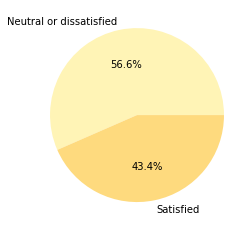

In [ ]:
plt.pie(al.satisfaction.value_counts(), labels = ["Neutral or dissatisfied", "Satisfied"], 
colors = sns.color_palette("YlOrBr"), autopct = '%1.1f%%')
pass

####The amount of dissatisfied/neutral passengers are more than satisfy.

## who is more satisfied based on customer class?

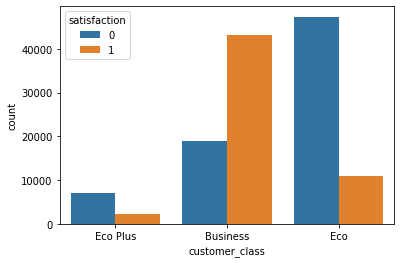

In [ ]:
sns.countplot(x = 'customer_class', hue = 'satisfaction', data = al)
plt.show()

#### passengers that uses Business class are more satisfied, while the least satisfied are Eco plus class.

### who is more satisfied based on online booking?

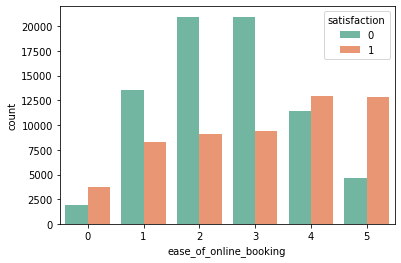

In [ ]:
ax=sns.countplot(x = 'ease_of_online_booking', hue = 'satisfaction', palette = "Set2", data = al)
plt.show()

almost all passengers who rated the online booking 5 out of 5 were satisfied with the flight.


##The dependences of the arrival and departure dalay in minutes .

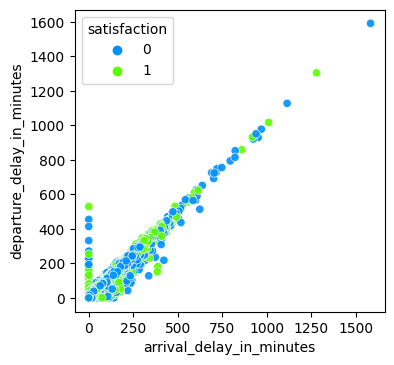

In [ ]:
plt.figure(figsize=(4,4), dpi=100)
sns.scatterplot(data=al,x='arrival_delay_in_minutes',y='departure_delay_in_minutes'
,hue='satisfaction',palette='gist_rainbow_r',alpha=0.9)

if the flight was delayed by a certain amount of time at departure, then the flight will be delayed by about the same amount of time arriving.

##Does the seat comfort affect at the passenger satisfaction ?

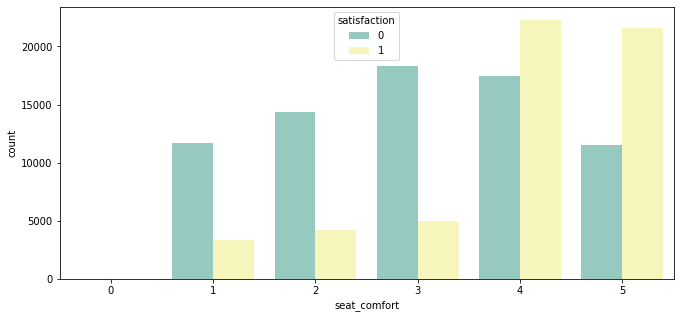

In [ ]:
ax= plt.subplots(1,figsize = (11,5))
sns.countplot(x ='seat_comfort', hue = 'satisfaction', palette = "Set3", data = al)

####ratio between satissfied and disstaified passegngers is higher when the seat comfort is higher

###What is the usualy average of age based on customer class?

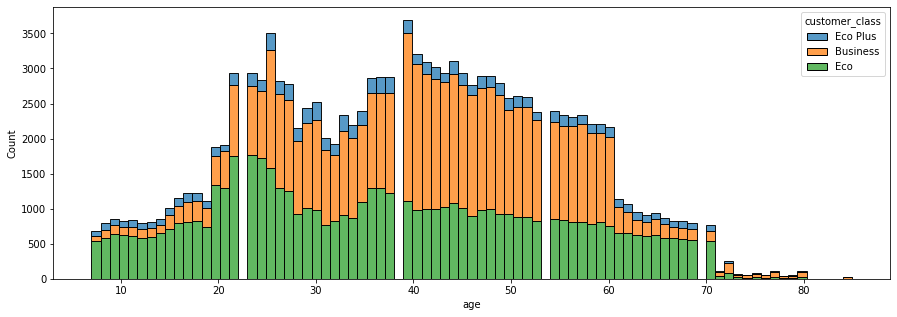

In [ ]:
ax = plt.subplots(1, figsize = (15,5))
sns.histplot(al, x = "age", hue = "customer_class", multiple = "stack")

### The average of passengers usualy uses Economy plus


### What are the most purposes passengers travel for ?

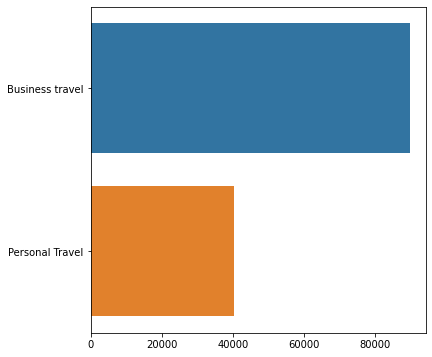

In [ ]:
startstation = al['type_of_travel'].value_counts()[:15]
plt.figure(figsize=(6,6))
sns.barplot( x=startstation.values , y=list(startstation.index), 
 orient="h"  ) 

most of them fly for business rather than personal reasons.

###what is the relationship between flight distance and customer class?

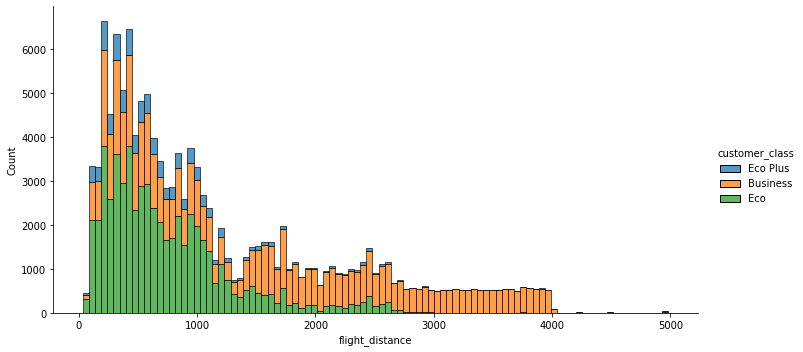

In [ ]:
sns.displot(data=al, x='flight_distance', hue='customer_class', multiple='stack',  aspect=10/5) ;

####passengers whose flight distance is long,they usually fly in business class.